In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

from configurations import load_data, set_font_sizes, create_fig, apply_general_styles

apply_general_styles()

1.0
-1.3877787807814457e-17
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
H_u: 3.7826
H_b: 3.2879
C_beta: -0.8304
H_u - C_beta: 4.6129    


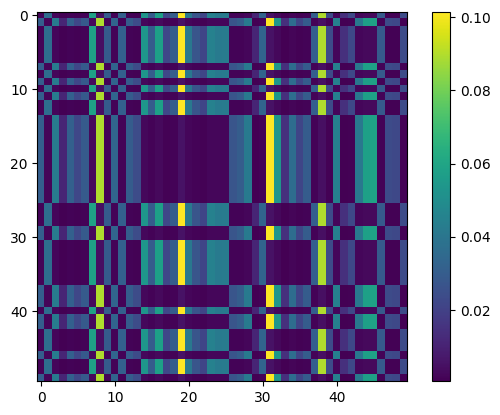

logV =  3.912023005428146


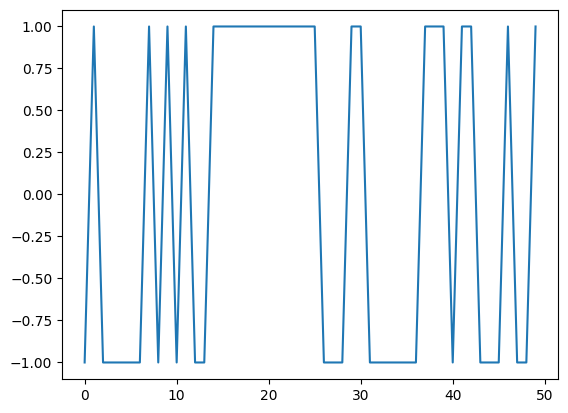

In [51]:
V = 50
beta = 0.9

u = np.ones(V) 
u[V//2:] = -1  # First half +1, second half -1

rnd = np.random.randn(V//2) * 0.5
P_u = np.concatenate([rnd,rnd]) # (V,)
P_u = np.exp(P_u) / np.exp(P_u).sum()  # Normalize to sum to 1

idx = np.random.permutation(V)
u = u[idx]
P_u = P_u[idx]
P_b = P_u[None,:] * (1 - beta*u[:,None]*u[None,:])  # (V, V)

print(np.sum(P_u))  # Should be 1
print(np.sum(P_u*u))
print(np.sum(P_b,axis=1))  # Should be 1 for each row

plt.imshow(P_b, cmap='viridis')
plt.colorbar()

H_u = -np.sum(P_u * np.log(P_u)) # Entropy of P_u  
H_b = -np.sum(P_b * P_u[:,None] * np.log(P_b))  # Cross-entropy of P_b with respect to P_u

print(f'H_u: {H_u:.4f}')
print(f'H_b: {H_b:.4f}')

C_beta = 0.5*math.log(1-beta**2)  # Capacity of the channel
print(f'C_beta: {C_beta:.4f}'   )
print(f'H_u - C_beta: {H_u - C_beta:.4f}    ')
plt.show()
plt.plot(u, label='P_u')

print('logV = ', math.log(V))

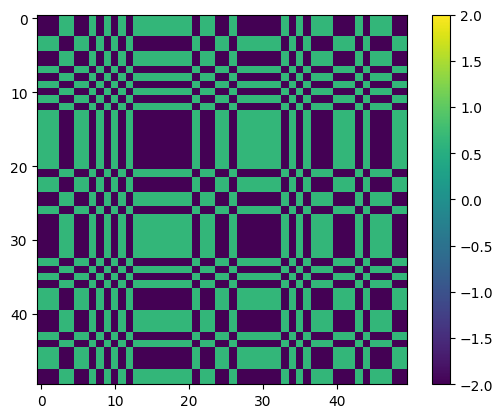

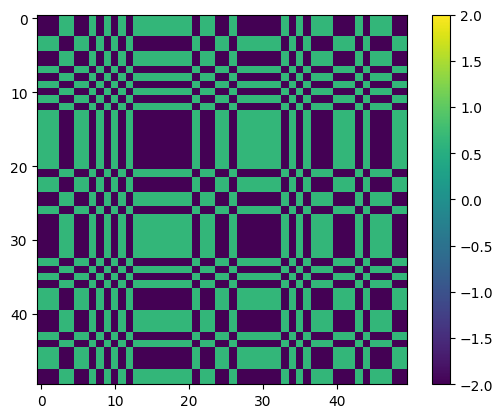

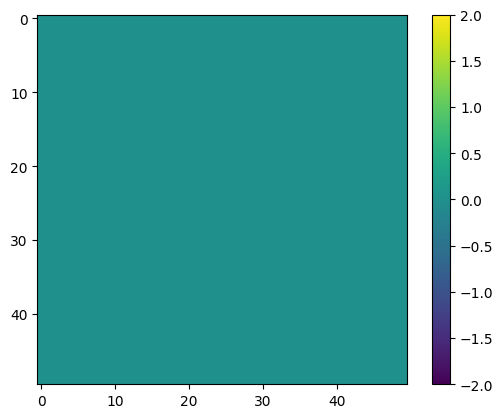

In [50]:
X = 1 - beta * u[:,None] * u[None,:]
Y1 = np.log(X)  # Logarithm of the channel matrix

Y2 = - u[:,None] * u[None,:] * math.atanh(beta)  + 0.5 * np.log(1 - beta**2)  # Approximation of the log of the channel matrix
plt.imshow(Y1, cmap='viridis',vmax=2, vmin=-2)
plt.colorbar()
plt.show()
plt.imshow(Y2, cmap='viridis',vmax=2, vmin=-2)
plt.colorbar()
plt.show()
plt.imshow(Y1-Y2, cmap='viridis',vmax=2, vmin=-2)
plt.colorbar()

In [13]:
# Load picke

data = load_data('temp',experiment_name='tmp')

for key, value in data.items():
    print(f"{key}: {value.shape}")


# data['input']

File temp.pkl loaded with pickle.load from /u/c/cerazova/SAM/data/tmp
S1: (10, 15, 15)
A1: (10, 15, 15)
Y1: (10, 15, 1000)
S2: (10, 15, 15)
A2: (10, 15, 15)
Y2: (10, 15, 1000)
X2: (10, 15, 1000)
Y3: (10, 15, 1000)
X3: (10, 15, 1000)
logits: (10, 15, 20)
logits_X2: (10, 15, 20)
logits_Y3: (10, 15, 20)
input: (10, 15)


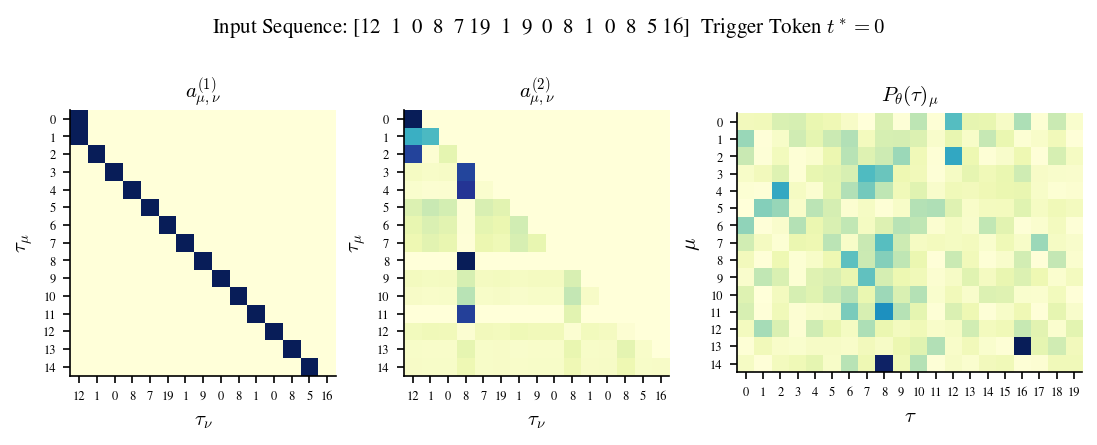

In [49]:
# Settings
i_batch = 8
cmap = 'YlGnBu'

set_font_sizes(conf='tight')

# Plots
fig , axes = create_fig(ncols=3,size='double',h=0.4,w=1,w_ratios=[1,1,1.3],
                        sharex=False, sharey=False)

for i , ax in enumerate(axes[:2]):
    A = data[f'A{i+1}'][i_batch]  # shape (seq_len, seq_len)
    ax.set_title(rf'$a^{{({i+1})}}_{{\mu,\nu}}$')
    ax.set_xlabel(r'$\tau_\nu$')
    ax.set_ylabel(r'$\tau_\mu$')
    input = data['input'][i_batch]
    im = ax.imshow(A, cmap=cmap)#,vmax=0.3)
    # plt.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(A.shape[0]),input)
    ax.set_yticks(np.arange(A.shape[0]))

ax = axes[2]
log = 0.5*data['logits'][i_batch] # shape (seq_len, vocab_size)
P = np.exp(log) / np.exp(log).sum(axis=-1, keepdims=True)  # shape (seq_len, vocab_size)
im = ax.imshow(P, cmap=cmap)#,vmax=0.3)
# plt.colorbar(im, ax=ax)
ax.set_ylabel(r'$\mu$')
ax.set_xlabel(r'$\tau$')
ax.set_title(r'$P_\theta(\tau)_\mu$')
ax.set_xticks(np.arange(log.shape[1]))
ax.set_yticks(np.arange(log.shape[0]))

fig.suptitle(f'Input Sequence: {data["input"][i_batch]} '+r' Trigger Token $t^*=0$')
plt.show()

In [35]:
math.sqrt(1000)

31.622776601683793

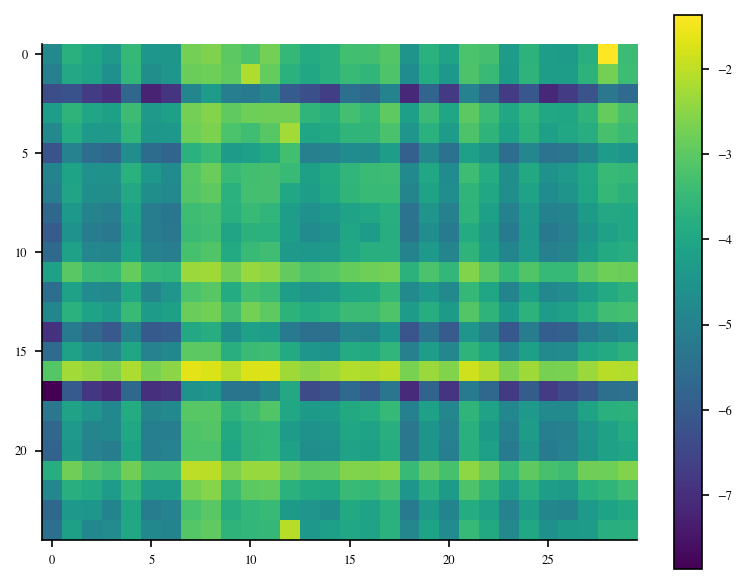

In [54]:
E = data['E'] # shape (vocab_size, d_model)
U = data['U'] # shape (vocab_size, d_model)
Y1 = data['Y1'][i_batch]  # shape (seq_len, d_model)
Y2 = data['Y2'][i_batch]  # shape (seq_len, d_model)
X2 = data['X2'][i_batch]  # shape (seq_len, d_model)
Y3 = data['Y3'][i_batch]  # shape (seq_len, d_model)
W0V1 = data['WOV1'] # shape (vocab_size, d_model)
projected_Y1 = Y1 @ (E @ W0V1.T).T
projected_Y2 = (X2+Y3) @ U.T
plt.imshow(projected_Y2, cmap='viridis')
plt.colorbar()

In [126]:
import torch
from sam.dataset import get_distributions, get_sample_dual_task


tensor(1.0000)
tensor([2.3145e-02, 4.5203e-03, 5.6859e-04, 6.2244e-03, 5.0221e-01, 1.5188e-02,
        5.4994e-02, 8.9122e-02, 2.4088e-02, 2.5148e-04, 1.4742e-02, 1.1110e-02,
        6.0541e-02, 7.0085e-02, 1.0828e-03, 3.2734e-04, 1.5791e-03, 2.8214e-02,
        8.3918e-02, 8.0891e-03])
tensor([0.2247, 0.0194, 0.0077, 0.2110, 0.0222, 0.0370, 0.0235, 0.0213, 0.0224,
        0.0455, 0.1235, 0.0219, 0.0206, 0.0116, 0.0183, 0.0482, 0.0340, 0.0327,
        0.0264, 0.0280])
tensor(1.0000)
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000])


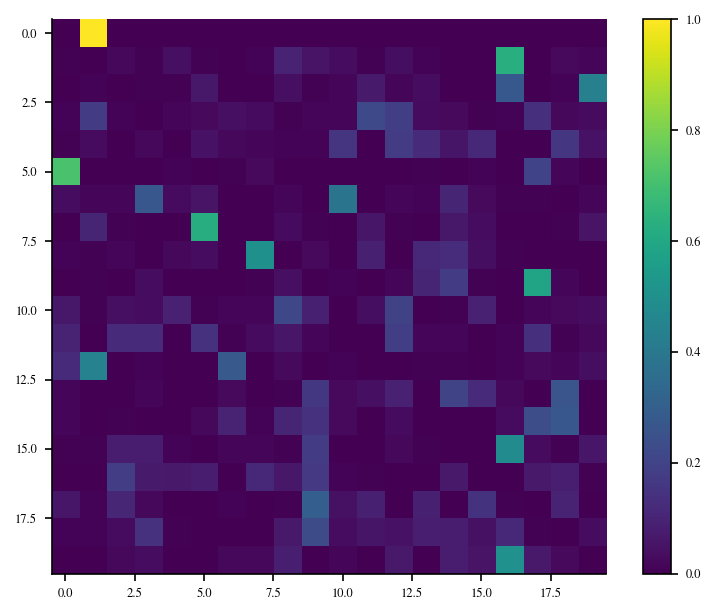

In [142]:
V = 20
mode = 'random'
P_b, P_u, P_o, P_t = get_distributions(V,mode, beta=2.0)
P_tot = P_b * P_u[:,None]  # shape (V, V)
P_marginal = P_tot.sum(axis=0)  # shape (V,)
idx = torch.argsort(P_marginal, descending=True)
P_u = P_u[idx]
P_b = P_b[:,idx]

P_o[0] = 0.0
P_o[0,1]= 1.0
print(P_u.sum())  # Should be 1
print(P_tot.sum(axis=1))  # Should be 1 for each row
print(P_tot.sum(axis=0))  # Should be 1 for each column
print(P_tot.sum())
print(torch.sum(P_b,dim=1))  # Should be 1
plt.imshow(P_o, cmap='viridis')
plt.colorbar()

In [152]:
trigger_set = [0]
L = 200
input = get_sample_dual_task(200+L,P_b,P_u,P_o,trigger_set)[0][:L]
print(input)

tensor([14, 15,  0,  1, 10, 10,  4,  4,  0,  1,  7,  2,  1,  8,  8,  4,  1,  7,
        14, 19,  3,  9,  7,  2, 12, 15,  7,  2,  3, 17,  4,  0,  1,  8, 10, 15,
        10,  4,  1, 17, 14, 15, 11,  6, 17, 12, 13,  3, 19,  8,  8, 10,  0,  1,
        17, 12, 13,  3, 12,  0,  1,  2,  0,  1, 10,  0,  1, 10, 16, 13,  3, 12,
        11, 15,  5,  6,  6,  7,  2,  8,  1,  8,  8,  1,  8, 16, 13,  5,  3, 17,
         4,  1, 17, 16, 13,  3, 17, 14,  8,  8, 17,  4,  0,  1,  7,  5,  3, 17,
        14, 15, 18,  2,  2,  2, 17,  4,  0,  1,  7, 15,  8, 13,  9,  7, 14, 15,
         1, 10,  4,  1,  8,  1,  7, 10, 16, 13,  7,  5,  3, 17, 14, 15,  8, 10,
        15,  8,  8,  4,  1,  8,  8, 16, 13,  5,  9, 18,  2, 17, 11,  3, 17, 11,
        13, 16, 13,  9,  7, 15,  8,  4,  5,  6,  3, 17, 12, 17,  4,  0,  1, 10,
        10, 16, 12,  2,  2,  0,  1, 13,  3, 17, 14, 18,  2,  0,  1, 17, 14, 17,
        11,  6])


In [153]:
values , counts = torch.unique(input, return_counts=True)
idx = torch.argsort(counts, descending=True)
values = values[idx]
counts = counts[idx]

print(values)
print(counts)

tensor([ 1,  8, 17, 10,  0,  4,  3,  2,  7, 13, 15, 14, 12, 16,  5,  6, 11,  9,
        18, 19])
tensor([22, 19, 18, 12, 12, 12, 12, 12, 11, 11, 11,  9,  7,  7,  6,  5,  5,  4,
         3,  2])
